In [1]:
import os
import time
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, DataCollatorForTokenClassification,
    DataCollatorWithFlattening
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import (accuracy_score,classification_report, 
confusion_matrix, balanced_accuracy_score, f1_score)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

GPU disponible: True
Modelo de GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
#Extracción de rutas para la lectura y derivación de archivos
PROJECT_ROOT = Path(os.getcwd()).parent

# Ruta completa a carpetas
MODELOS_PATH = PROJECT_ROOT / 'modelos'/'Borrar'
DATOS_PATH = PROJECT_ROOT / 'data' / 'limpieza_final' / 'etiquetado_humano_unificado.csv'
print(str(MODELOS_PATH))
print(str(DATOS_PATH))
corpus = pd.read_csv(DATOS_PATH, usecols = ['comentario', 'etiquetado_humano','categoria'],encoding = 'utf-8-sig')
print(corpus.head())

C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\modelos\Borrar
C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\data\limpieza_final\etiquetado_humano_unificado.csv
                                          comentario  etiquetado_humano  \
0  cuál es el más cercado para rayar el nombre de...                3.0   
1  esos baños deberian estar en el metro no saben...                2.0   
2                           no pues bueno me da risa                3.0   
3                                los van a abandonar                2.0   
4                           nada los tiene contentos                4.0   

         categoria  
0  infraestructura  
1  infraestructura  
2  infraestructura  
3  infraestructura  
4  infraestructura  


In [3]:
#Nos quedamos unicamente con los datos que tienen etiqueta, pues estamos
#realizando un aprendizaje supervisado
muestra = corpus[np.isnan(corpus['etiquetado_humano']) == False]

#Se renombran la columnas columnas 'etiquetado_humano' y 'comentario' 
#como 'labels' y 'text' como requerimiento para hacer el fine tuning
muestra.rename(columns = {'etiquetado_humano':'labels','comentario':'text'}, inplace = True)
muestra['labels'] = [int(x-1) for x in muestra['labels']]

#Para evitar problemas de correlacion (inducidos por las categorias),
#hacemos un reordenamiento aleatorio de nuestros datos
muestra = muestra.sample(n = len(muestra['text']))
muestra_ds = Dataset.from_pandas(muestra)


print(muestra.head())

semilla = 61298

                                                   text  labels  \
6                                              no maaaa       1   
162               la primera señora tiene toda la razón       2   
891   pongan subtitulos en inglés para que se haga e...       2   
1848  no mija ya es diciembre el bono y pues no marc...       2   
1816  y si mandamos una petición a la fifa para que ...       0   

            categoria  
6     infraestructura  
162   infraestructura  
891         seguridad  
1848          turismo  
1816          turismo  


In [4]:
# Cargamos el tokenizador del modelo que decidimos usar
modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer = AutoTokenizer.from_pretrained(modelo)

#Funcion simple para pasar de lenguaje natural a 'lenguaje de LLM'
def tokenizar(dato):
    return tokenizer(dato['text'], truncation = True, max_length = 580, padding = False)

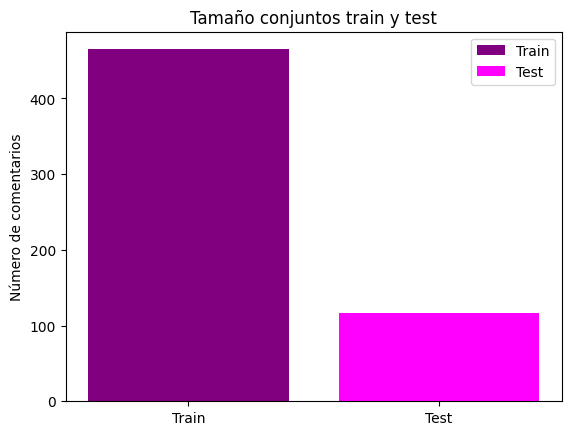

In [5]:
tam_train = len(muestra) * .8
tam_test = len(muestra) * .2

plt.bar(['Train','Test'],[tam_train,tam_test], label = ['Train','Test'],color = ['purple','magenta'])
plt.title('Tamaño conjuntos train y test')
plt.ylabel('Número de comentarios')
plt.legend()
plt.show()

In [6]:
#Primero definimos el clasificador al que le haremos el finefuning y los parametros necesarios para el mismo,
#entre ellos, las etiquetas de "ida y de vuelta" de la clasificacion
clasificador = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels = 5,
    id2label= {0:'Negativo',1:'Parcialmente Negativo', 2:'Neutral',3:'Parcialmente Positivo', 4:'Postivo'},
    label2id={'Negativo':0,'Parcialmente Negativo':1, 'Neutral': 2, 'Parcialmente Positivo': 3, 'Positivo':4}
)

#Ahora, configuramos LORA
lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,   # clasificación de secuencias
    r=16,              # rango: dimensión de las matrices B y A
                      # valores típicos: 4, 8, 16, 32, 64
                      # mayor r = más capacidad, más parámetros
    lora_alpha=32,    # escala: controla cuánto pesa ΔW vs W original
                      # regla general: lora_alpha = 2 * r
                      # el peso efectivo es (lora_alpha / r) * BA
    lora_dropout=0.1, # dropout aplicado a las capas LoRA (regularización)
    bias='none',      # no adaptar los sesgos (más eficiente)
    target_modules=[  # ¿en qué capas de BERT aplicar LoRA?
        'query',      # proyección Q en self-attention
        'value',      # proyección V en self-attention
        # 'key', 'dense' — se pueden agregar para más capacidad
    ],
)

#El fine tuning lo hacemos con lora a traves de peft:
#Parameter-Efficient Fine-Tuning (PEFT) methods enable efficient adaptation of large pretrained models 
#to various downstream applications by only fine-tuning a small number of (extra) model parameters 
#instead of all the model's parameters. This significantly decreases the computational and storage costs. 
#Recent state-of-the-art PEFT techniques achieve performance comparable to fully fine-tuned models.
clasificador_peft = get_peft_model(clasificador, lora_config)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [7]:
#Definimos las metricas con las que evaluaremos el modelo
#Ademas de reemplazar el trainer convencional de Transformers por un trainer
#con ponderaciones
def metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predicciones, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predicciones, average='weighted', zero_division=0)
    accuracy = (predicciones == labels).mean()
    bal_accuracy = balanced_accuracy_score(labels,predicciones)
    return {'f1_macro': f1_macro, 'f1_weighted': f1_weighted,'accuracy': accuracy,'balanced accuracy':bal_accuracy}



# Trainer personalizado
class WeightedLossTrainer(Trainer):
    """Trainer que usa class weights para manejar clases desbalanceadas"""
    
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    # num_items_in_batch=num_items_in_batch
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch = 0):
        """
        Sobrescribe el método compute_loss para usar class weights
        """
        labels = inputs.get("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        # Calcular loss con pesos si están disponibles
        if self.class_weights is not None:
            device = labels.device
            weights = self.class_weights.to(device)
            
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            # Fallback a loss estándar
            loss = outputs.loss
            
        return (loss, outputs) if return_outputs else loss



# Función para calcular pesos desde un dataset
def calcular_class_weights(dataset, num_labels=5):
    """
    Calcula los pesos de clase a partir de un dataset de Hugging Face
    
    Args:
        dataset: Dataset de Hugging Face con columna 'label'
        num_labels: número de clases
    
    Returns:
        torch.Tensor con los pesos para cada clase
    """
    # Extraer todas las etiquetas del dataset
    #print(dataset)
    labels = [example['labels'] for example in dataset]
    
    # Calcular pesos usando sklearn
    class_weights = compute_class_weight(
        class_weight='balanced',  # inversamente proporcional a frecuencia
        classes=np.unique(labels),
        y=labels
    )
    
    # Convertir a tensor de torch
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    '''
    # Mostrar información (opcional)
    print(f"\n  📊 Distribución en entrenamiento:")
    for i in range(num_labels):
        count = labels.count(i)
        print(f"     Clase {i}: {count:5d} ejemplos, Peso = {weights_tensor[i]:.4f}")
    '''
    return weights_tensor

In [8]:
def guardar_modelo_fold(trainer, tokenizer, modelos_path, fold_idx, eval_results=None):
    """
    Guarda el modelo fine-tuneado de un fold específico.
    En PEFT/LoRA guarda principalmente el adaptador LoRA.
    """
    
    carpeta_fold = Path(MODELOS_PATH) / f"Modelo_fold_{fold_idx + 1}"
    carpeta_fold.mkdir(parents=True, exist_ok=True)

    # Guardar modelo / adaptador LoRA
    trainer.model.save_pretrained(carpeta_fold)

    # Guardar tokenizer
    tokenizer.save_pretrained(carpeta_fold)

    # Guardar métricas del fold
    if eval_results is not None:
        with open(carpeta_fold / "metricas.json", "w", encoding="utf-8") as f:
            json.dump(eval_results, f, indent=4, ensure_ascii=False)

    print(f"Modelo del fold {fold_idx + 1} guardado en: {carpeta_fold}")
    
    return

#Una especie de preprocesado (o cargado) del tokenizador para 
#utilizarlo despues en el tuneo
colador = DataCollatorWithPadding(tokenizer = tokenizer)
#colador = DataCollatorWithFlattening(tokenizer = tokenizer)
#colador = DataCollatorForTokenClassification(tokenizer = tokenizer)


training_args = TrainingArguments(
    output_dir = MODELOS_PATH,

    # Épocas y batch
    num_train_epochs=7,              # 3 épocas suele ser suficiente para LoRA
    per_device_train_batch_size=8,  # ejemplos por paso en GPU
    per_device_eval_batch_size=16,

    # Learning rate
    learning_rate=1e-4,              # más alto que full FT (1e-5 a 5e-5)
                                     #
                                     #LoRA puede tolerar LR más altos
    lr_scheduler_type='cosine',      # decae suavemente hasta 0
    warmup_steps=0.1,                # 10% de pasos para calentamiento

    # Evaluación y guardado
    eval_strategy='epoch',           # evaluar al final de cada época
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='balanced accuracy',
    greater_is_better=True,

    # Eficiencia
    fp16=torch.cuda.is_available(),  # precisión mixta si hay GPU
    dataloader_num_workers=2,

    # Logging
    logging_steps=50,
    report_to='none',                # desactivar wandb/tensorboard
)

# Mover modelo al dispositivo
if device == 'cuda':
    clasificador_peft = clasificador_peft.to('cuda')


def entrenar_cv(folds_cv, modelo, tokenizer, num_epochs=3):
    """Entrena un modelo para cada fold y devuelve métricas"""
    
    resultados = []
    
    for fold_idx, fold in enumerate(folds_cv):
        print(f"\n{'='*50}")
        print(f"Entrenando Fold {fold_idx + 1}/{len(folds_cv)}")
        print(f"{'='*50}")
        
        #Calcular class weights desde el dataset de entrenamiento de este fold
        class_weights = calcular_class_weights(fold['train'], num_labels=5)

        clasificador = AutoModelForSequenceClassification.from_pretrained(
            modelo,
            num_labels=5,
            id2label={0:'Negativo',1:'Parcialmente Negativo', 2:'Neutral',3:'Parcialmente Positivo', 4:'Positivo'},
            label2id={'Negativo':0,'Parcialmente Negativo':1, 'Neutral': 2, 'Parcialmente Positivo': 3, 'Positivo':4}
        )

        # Configuramos LORA
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=32,
            lora_alpha=64,
            lora_dropout=0.2,
            bias='lora_only',
            target_modules=['query', 'value', 'key', 'dense'],
        )
        
        modelo_lora = get_peft_model(clasificador, lora_config)
        if device == 'cuda':
            modelo_lora = modelo_lora.to('cuda')
        
        #Usar WeightedLossTrainer en lugar de Trainer estándar
        trainer = WeightedLossTrainer(
            model = modelo_lora,
            args = training_args,
            train_dataset = fold['train'],
            eval_dataset = fold['validation'],
            data_collator = colador,
            compute_metrics = metricas,
            class_weights = class_weights,  # Aquí pasamos los pesos
        )
        
        # Entrenar
        trainer.train()
        
        # Evaluar
        eval_results = trainer.evaluate()
        eval_results['fold'] = fold_idx + 1
        resultados.append(eval_results)

         # Guardar modelo fine-tuneado del fold
        guardar_modelo_fold(
            trainer=trainer,
            tokenizer=tokenizer,
            modelos_path=MODELOS_PATH,
            fold_idx=fold_idx,
            eval_results=eval_results
        )
        
        #Limpiar memoria para el siguiente fold
        del modelo_lora
        del clasificador
        del trainer
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Mostrar resultados promedio
    print("\n" + "="*50)
    print("RESULTADOS FINALES DE CROSS VALIDATION")
    print("="*50)
    
    print(resultados)
    accuracies = [r['eval_accuracy'] for r in resultados]
    accuracies_bal = [r['eval_balanced accuracy'] for r in resultados]
    f1_scores = [r['eval_f1_weighted'] for r in resultados]
    
    print(f"Accuracy promedio: {np.mean(accuracies):.4f} (±{np.std(accuracies):.4f})")
    print(f"Accuracy balanceada promedio: {np.mean(accuracies_bal):.4f} (±{np.std(accuracies_bal):.4f})")
    print(f"F1-Score promedio: {np.mean(f1_scores):.4f} (±{np.std(f1_scores):.4f})")
    
    return resultados

Realizamos ahora el tuneo usando 5-cross validation, seleccionando el modelo con el balanced accuracy más alto.

In [9]:
#k-cross validation para fine tuning
def k_cross_folds(dataset, k=5, seed=61298):
    """Usa KFold de scikit-learn para crear los folds"""
    kf = KFold(n_splits = k, shuffle = True, random_state = seed)
    
    # Convertir a lista de índices
    indices = list(range(len(dataset)))
    
    folds = []
    for train_idx, val_idx in kf.split(indices):
        folds.append({
            'train': dataset.select(train_idx),
            'validation': dataset.select(val_idx)
        })
    
    return folds

# K-Fold simple

folds = k_cross_folds(muestra_ds, k=10, seed=semilla)
#print(folds)

folds_tokenizados = []
for j in folds:
    #print(j)
    j = DatasetDict({'train': j['train'], 'validation': j['validation'],
                         'test': j['validation']})    
    folds_tokenizados.append(j.map(tokenizar, batched=True, remove_columns=['text']))

modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
#Finalmente entrenamos y revisamos metricas con 5-cross validation
inicio = time.time()
tokenizer = AutoTokenizer.from_pretrained(modelo)
resultados_cv = entrenar_cv(
    folds_cv=folds_tokenizados,
    modelo=modelo,
    tokenizer=tokenizer,
    num_epochs=3
)
fin = time.time()
tiempo_total = fin - inicio


print(f"\nEntrenamiento completo.")
print(f"Tiempo total: {tiempo_total:.4f}s") 

Map:   0%|          | 0/522 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Map:   0%|          | 0/523 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

...

Modelo del fold 9 guardado en: C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\modelos\Borrar\Modelo_fold_9

Entrenando Fold 10/10


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
1,1.579275,1.460447,0.272515,0.427506,0.431034,0.376786
2,1.516865,1.500135,0.217802,0.313334,0.344828,0.327976
3,1.374813,1.456381,0.438836,0.511777,0.500000,0.517857
4,0.951706,1.456674,0.367173,0.449037,0.431034,0.485714
5,0.918856,1.482879,0.406628,0.479846,0.465517,0.511310
6,0.700956,1.476422,0.390847,0.470864,0.465517,0.519048
7,0.636522,1.479350,0.411508,0.509442,0.500000,0.541071


Training Loss,Validation Loss,Epoch,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
0.636522,1.479350,7,0.411508,0.509442,0.500000,0.541071


Modelo del fold 10 guardado en: C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\modelos\Borrar\Modelo_fold_10

RESULTADOS FINALES DE CROSS VALIDATION
[{'eval_loss': 2.355020761489868, 'eval_f1_macro': 0.2820337253067387, 'eval_f1_weighted': 0.4566558050135642, 'eval_accuracy': 0.4406779661016949, 'eval_balanced accuracy': 0.2714035087719298, 'fold': 1}, {'eval_loss': 1.7034083604812622, 'eval_f1_macro': 0.390859501695415, 'eval_f1_weighted': 0.5279146141215106, 'eval_accuracy': 0.5172413793103449, 'eval_balanced accuracy': 0.4637727898176815, 'fold': 2}, {'eval_loss': 1.8105303049087524, 'eval_f1_macro': 0.5976836368140716, 'eval_f1_weighted': 0.6252215772455653, 'eval_accuracy': 0.6379310344827587, 'eval_balanced accuracy': 0.5950187969924812, 'fold': 3}, {'eval_loss': 1.6320478916168213, 'eval_f1_macro': 0.31097643097643096, 'eval_f1_weighted': 0.47234413096482064, 'eval_accuracy': 0.5, 'eval_balanced accuracy': 0.3307664884135472, 'fold': 4}, {'eval_loss': 1.99395227432250

Echemosle un pequeño ojo a nuestro modelo fine tuneado:

In [10]:
modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
fold_bueno = folds_tokenizados[6]


##################################################################################################################################################


class_weights = calcular_class_weights(fold_bueno['train'], num_labels=5)

clasificador = AutoModelForSequenceClassification.from_pretrained(
            modelo,
            num_labels=5,
            id2label={0:'Negativo',1:'Parcialmente Negativo', 2:'Neutral',3:'Parcialmente Positivo', 4:'Positivo'},
            label2id={'Negativo':0,'Parcialmente Negativo':1, 'Neutral': 2, 'Parcialmente Positivo': 3, 'Positivo':4}
        )

        # Configuramos LORA
lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=32,
            lora_alpha=64,
            lora_dropout=0.2,
            bias='lora_only',
            target_modules=['query', 'value', 'key', 'dense'],
        )
        
modelo_lora = get_peft_model(clasificador, lora_config)
if device == 'cuda':
    modelo_lora = modelo_lora.to('cuda')
        
        #Usar WeightedLossTrainer en lugar de Trainer estándar
trainer = WeightedLossTrainer(
            model=modelo_lora,
            args=training_args,
            train_dataset=fold_bueno['train'],
            eval_dataset=fold_bueno['validation'],
            data_collator=colador,
            compute_metrics=metricas,
            class_weights=class_weights,  # ← ¡Aquí pasamos los pesos!
        )
        
# Entrenar
trainer.train()
        
# Evaluar
eval_results = trainer.evaluate()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
1,1.615122,1.379518,0.185621,0.315979,0.327586,0.244858
2,1.445528,1.234160,0.295269,0.506596,0.517241,0.370736
3,1.352791,1.325570,0.285640,0.500962,0.517241,0.357483
4,0.960170,1.216839,0.372491,0.531199,0.517241,0.494858
5,0.848155,1.342964,0.323149,0.470279,0.482759,0.444774
6,0.852231,1.396551,0.268390,0.469195,0.465517,0.328135
7,0.633891,1.411095,0.268390,0.469195,0.465517,0.328135


Training Loss,Validation Loss,Epoch,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
0.633891,1.219593,7,0.378684,0.533625,0.517241,0.501589


In [11]:
ruta_modelo = "modelos/sentiment_lora_fold_7"

trainer.model.save_pretrained(MODELOS_PATH)